In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Linear Recurrence and State Space Models

The gated cells of that section solved the memory problem and promptly
ran into a compute problem. A recurrent network must consume its input one
step at a time: $\mathbf{H}_t$ cannot be computed before
$\mathbf{H}_{t-1}$ exists, so a sequence of length $T$ costs $T$
*sequential* rounds of work no matter how many processors we own. Modern
accelerators are throughput machines, built to run tens of thousands of
threads at once, and a recurrence at inference batch sizes leaves nearly all
of them idle. Compare the convolutional networks of that section: a
convolution applies the same weights at every position, just as a recurrence
applies the same cell at every step, but all positions are computed *at
once*. That difference in training throughput, far more than any difference
in modeling power, is what pushed recurrent networks out of large-scale use.

This section is about getting the parallelism back without giving up the
thing that makes recurrence attractive: a state of fixed size, updated in
constant time per token at inference (that section).
The obstacle turns out to be the nonlinearity wrapped around the state
update, and the section removes it in two passes. First we strip the GRU
down to a minimal gated cell whose update is *linear* in the state, which
makes the whole sequence computable by a parallel *scan* in logarithmic
depth. Then we rebuild the linear recurrence properly, starting from a
continuous-time *state space model* (SSM): discretization will hand us
principled gates, stability by construction rather than by hope, an exact
equivalence between recurrence and convolution, and, through the HiPPO
theory, a principled answer to what dynamics make a fixed-size state a
good memory of the past. The result, the S4 family of models
[@Gu.Goel.Re.2022], is the backbone of the selective state space
models we meet in the next section and of recurrent layers inside several
production language models.

*Prerequisites: the gated cells and language-modeling recipe of
that section, the gradient analysis of
that section, and, for the classifier
experiment, Fashion-MNIST from that section.*

In [1]:
%matplotlib inline
from d2l import jax as d2l
from flax import nnx
import jax
from jax import numpy as jnp
import math
import numpy as np
import optax
import time

## Linearizing the Recurrence

Why exactly can a recurrence not be parallelized? Take the vanilla update
$\mathbf{H}_t = \phi(\mathbf{X}_t \mathbf{W}_{\textrm{xh}} +
\mathbf{H}_{t-1} \mathbf{W}_{\textrm{hh}} + \mathbf{b})$ and try to jump
ahead two steps: substituting the update into itself buries
$\mathbf{H}_{t-2}$ under two nested applications of $\phi$, and nothing
simplifies. A composition of nonlinear maps has no compact closed form, so
the only way to evaluate step $t$ is to have evaluated step $t-1$. The
nonlinearity in the *state path* is the exact culprit. Everything else
about the cell, gates computed from the input, nonlinear read-outs of the
state, deep stacks of layers, creates no such obstruction.

That observation suggests a surgical experiment: keep the gating idea of
that section, but remove every appearance of $\mathbf{H}_{t-1}$
inside a nonlinearity. Recall the GRU update, the equation
through the equation: two gates and a candidate, each a function of
$\mathbf{X}_t$ *and* $\mathbf{H}_{t-1}$, followed by a convex blend.
@Feng.Tung.Ahmed.ea.2024 asked how much of that machinery is
load-bearing and arrived at the *minGRU* by making two cuts. First, the
update gate is computed from the input alone. Second, the candidate state
is computed from the input alone, which leaves the reset gate with nothing
to reset, so it is deleted outright. What survives is

$$
\mathbf{Z}_t = \sigma(\mathbf{X}_t \mathbf{W}_{\textrm{xz}} + \mathbf{b}_\textrm{z}),
\qquad
\tilde{\mathbf{H}}_t = \tanh(\mathbf{X}_t \mathbf{W}_{\textrm{xh}} + \mathbf{b}_\textrm{h}),
$$

$$
\mathbf{H}_t = (1 - \mathbf{Z}_t) \odot \mathbf{H}_{t-1} + \mathbf{Z}_t \odot \tilde{\mathbf{H}}_t.
$$

Here $\mathbf{Z}_t$ gates the write, so $\mathbf{Z}_t \approx 0$ means
"hold the state"; substituting $\mathbf{Z}_t \leftarrow 1 - \mathbf{Z}_t$
recovers the orientation of the equation. (Feng et al. also drop the
$\tanh$ on the candidate; we keep it because a bounded candidate trains
more stably under the plain SGD recipe we reuse below, and an exercise asks
you to remove it.) The cell looks almost unchanged, but its character is
transformed: for fixed inputs, the equation is an *affine* function
of $\mathbf{H}_{t-1}$,

$$
\mathbf{H}_t = \mathbf{a}_t \odot \mathbf{H}_{t-1} + \mathbf{b}_t,
\qquad
\mathbf{a}_t = 1 - \mathbf{Z}_t,
\quad
\mathbf{b}_t = \mathbf{Z}_t \odot \tilde{\mathbf{H}}_t,
$$

where every coefficient $\mathbf{a}_t, \mathbf{b}_t$ depends only on
$\mathbf{X}_t$ and hence can be computed for *all* $t$ simultaneously, in
one batched matrix product. Two consequences follow, and they organize the
rest of this section. Parallelism: affine maps compose into affine maps,
so the $T$-step recurrence can be evaluated by a divide-and-conquer scheme
rather than a left-to-right walk. Analyzable memory: unrolling
the equation shows that the input from $k$ steps ago
reaches $\mathbf{H}_t$ scaled by exactly
$\prod_{j=t-k+1}^{t} \mathbf{a}_j$, a product of gate values you can print,
plot, and reason about. Because $\mathbf{a}_t = 1 - \mathbf{Z}_t \in (0, 1)$
elementwise, that product can never explode, and how fast it decays is a
learned, per-unit property: the eigenvalue analysis of
that section applies with the eigenvalues in
plain sight. Linear recurrent units (LRUs) push the same idea further with
complex-valued decays and careful initialization, and match well-tuned
nonlinear RNNs on long-range benchmarks [@Orvieto.Smith.Gu.ea.2023].

Does linearity in the state cost us expressivity? Within a single layer,
yes: a linear state can only accumulate and forget, not compute. The
answer, as everywhere else in deep learning, is depth: nonlinearities
remain between layers, where they do not obstruct parallelism, and the
stack recovers the lost capacity. We will see the pattern concretely in
the S4D block near the end of this section.

## Parallel Scans

### An Associative Combine

The classic *prefix sum* problem asks for all running totals
$s_t = x_1 + \cdots + x_t$ of a sequence. It looks as sequential as our
recurrence, yet it parallelizes beautifully, because addition is
*associative*: sums may be grouped arbitrarily, so partial sums of blocks
can be computed independently and merged. The general result, due to
@Blelloch.1990, is that a running "total" under *any* associative
binary operator can be computed in $O(\log T)$ parallel rounds; the
operation is called a *parallel scan*, and it is exactly as general as it
sounds.

Our recurrence fits once we find the right operator. Represent the affine
update at step $t$ by its coefficient pair $(\mathbf{a}_t, \mathbf{b}_t)$,
standing for the map $\mathbf{h} \mapsto \mathbf{a}_t \odot \mathbf{h} +
\mathbf{b}_t$. Applying $(\mathbf{a}_1, \mathbf{b}_1)$ first and
$(\mathbf{a}_2, \mathbf{b}_2)$ second gives
$\mathbf{a}_2 \odot (\mathbf{a}_1 \odot \mathbf{h} + \mathbf{b}_1) +
\mathbf{b}_2$, which is again affine:

$$
(\mathbf{a}_2, \mathbf{b}_2) \circ (\mathbf{a}_1, \mathbf{b}_1)
= (\mathbf{a}_1 \odot \mathbf{a}_2,\ \mathbf{a}_2 \odot \mathbf{b}_1 + \mathbf{b}_2).
$$

The operator $\circ$ is associative because function composition is
associative, and composing the first $t$ pairs yields the map that carries
$\mathbf{h}_0$ all the way to $\mathbf{h}_t$; with
$\mathbf{h}_0 = \mathbf{0}$ the state is simply the $\mathbf{b}$-component
of that composite. So the entire trajectory
$\mathbf{h}_1, \ldots, \mathbf{h}_T$ is the prefix scan of
$(\mathbf{a}_1, \mathbf{b}_1), \ldots, (\mathbf{a}_T, \mathbf{b}_T)$
under the equation.

the figure shows the parallel schedule we will implement, on
eight elements. In round one, every position combines with its immediate
predecessor; in round two, with the position two back; then four back, and
so on, doubling the stride. After round $r$ position $t$ holds the
composite of elements $\max(1, t - 2^r + 1)$ through $t$, so after
$\lceil \log_2 T \rceil$ rounds every position holds its full prefix. Each
round is one batched elementwise multiply-add over the whole sequence,
perfect work for an accelerator.

![A parallel prefix scan on eight elements. Each round combines every position with the one a fixed stride back (arrows), doubling the stride each round; dashed arrows copy unchanged values. Labels show which input elements each node has absorbed; after $\log_2 8 = 3$ rounds, every position holds its full prefix (green).](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-modernrnn-scan-tree.svg)

This doubling schedule, the scheme of Hillis and Steele, performs
$O(T \log T)$ total work, a $\log T$ factor more than the sequential loop,
in exchange for $O(\log T)$ depth.
Blelloch's classic two-sweep scan gets the work back down to $O(T)$ at
slightly more than twice the depth; production kernels use it, and we
happily pay the log factor for code that fits on a slide.

### Implementation

We implement the doubling scan for the elementwise-affine recurrence
$\mathbf{h}_t = \mathbf{a}_t \odot \mathbf{h}_{t-1} + \mathbf{b}_t$ with
$\mathbf{h}_0 = \mathbf{0}$. Time runs along the first axis; any batch or
feature axes ride along elementwise, and the coefficient tensors follow
ordinary broadcasting rules, a convenience we will lean on later when
$\mathbf{a}$ is shared across the batch. Each iteration of the loop is one
round of the figure: positions $t < s$ keep their values (the
`[:s]` prefix), and every other position combines with the value at stride
$s$ by the equation. The function is built from differentiable
tensor ops, so gradients flow through training without further ado.

We save the helper in the `d2l` library: it is the computational core of
this section and the next.

JAX ships the scan as a primitive: `jax.lax.associative_scan` takes the
combine function and applies it in log depth. We only need to supply
the equation on `(a, b)` pairs.

In [2]:
def scan_combine(prev, cur):
    a_prev, b_prev = prev
    a_cur, b_cur = cur
    return a_prev * a_cur, a_cur * b_prev + b_cur

def associative_scan(a, b):
    """Parallel prefix scan for h_t = a_t * h_{t-1} + b_t with h_0 = 0."""
    return jax.lax.associative_scan(scan_combine, (a, b))[1]

Correctness first: on random coefficients (decays $\mathbf{a}_t$ drawn in
$(0, 1)$, a deliberately awkward length that is not a power of two), the
scan must agree with the sequential loop it replaces.

In [3]:
def sequential_scan(a, b):
    step = lambda h, ab: (ab[0] * h + ab[1],) * 2
    return jax.lax.scan(step, jnp.zeros_like(b[0]), (a, b))[1]

key1, key2 = jax.random.split(d2l.get_key())
a = jax.random.uniform(key1, (100, 4, 8))
b = jax.random.normal(key2, (100, 4, 8))
err = jnp.abs(associative_scan(a, b) - sequential_scan(a, b)).max()
print(f'maximum deviation: {float(err):.2e}')

maximum deviation: 4.77e-07


Now the payoff. We time the parallel scan against the sequential
evaluation as the sequence grows from 256 to 16,384 steps, at a fixed
batch of 32 sequences with 128 units.

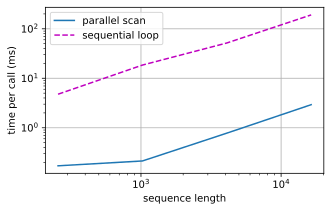

In [4]:
parallel_fn = jax.jit(associative_scan)
sequential_fn = jax.jit(sequential_scan)

def wall_clock(f, *args, reps=3):
    f(*args).block_until_ready()  # Warm up (and compile)
    start = time.time()
    for _ in range(reps):
        f(*args).block_until_ready()
    return (time.time() - start) / reps

lengths, times = [256, 1024, 4096, 16384], [[], []]
for T in lengths:
    key1, key2 = jax.random.split(jax.random.key(T))
    a = jax.random.uniform(key1, (T, 32, 128))
    b = jax.random.normal(key2, (T, 32, 128))
    times[0].append(wall_clock(parallel_fn, a, b) * 1e3)
    times[1].append(wall_clock(sequential_fn, a, b) * 1e3)
d2l.plot(lengths, times, 'sequence length', 'time per call (ms)',
         legend=['parallel scan', 'sequential loop'],
         xscale='log', yscale='log', figsize=(5, 3))

The sequential curve climbs linearly with $T$, dominated by the cost of
launching $T$ tiny dependent steps. The scan's curve stays well below it
at every length, by roughly an order of magnitude in our runs: its
handful of rounds are large batched operations that actually saturate the
hardware. This plot is the
"trains like a CNN" moment for recurrence, and everything else in this
section and the next is built on top of it. Note what the scan did *not*
change: at inference we still update
$\mathbf{h}_t = \mathbf{a}_t \odot \mathbf{h}_{t-1} + \mathbf{b}_t$ one
token at a time, in constant memory, exactly like any RNN. We cash that
claim, with a stopwatch, in that section.

### A minGRU Language Model

Assembling the equation through
the equation around the scan yields a drop-in
replacement for the recurrent cells of that section: same
`(inputs, state)` interface, no step-by-step loop. A carried-in state
folds into the first element, since
$\mathbf{h}_1 = \mathbf{a}_1 \odot \mathbf{h}_0 + \mathbf{b}_1$.

In [5]:
class MinGRU(nnx.Module):
    """The minimal GRU: input-only gates and a linear state path."""
    def __init__(self, num_inputs, num_hiddens, rngs=None):
        rngs = nnx.Rngs(0) if rngs is None else rngs
        self.num_inputs, self.num_hiddens = num_inputs, num_hiddens
        self.W_xz = nnx.Linear(num_inputs, num_hiddens, rngs=rngs)
        self.W_xh = nnx.Linear(num_inputs, num_hiddens, rngs=rngs)

    def __call__(self, inputs, H=None):
        Z = jax.nn.sigmoid(self.W_xz(inputs))    # (num_steps, batch, hiddens)
        H_tilde = jnp.tanh(self.W_xh(inputs))
        a, b = 1 - Z, Z * H_tilde
        if H is not None:  # Fold the carried-in state into the first step
            b = jnp.concatenate([b[:1] + a[:1] * H, b[1:]])
        outputs = associative_scan(a, b)
        return outputs, outputs[-1]

Is stripping the GRU this aggressively survivable? We rerun the exact
recipe of that section: *The Time Machine* under the 1,024-token
BPE tokenizer, 50,000 windows of 32 tokens, embedding dimension 64, 128
hidden units, ten epochs, gradients clipped to norm 1, so the numbers are
directly comparable with that section's scoreboard.

In [6]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32,
                       num_train=50000, num_val=5000)

In [7]:
mingru = MinGRU(num_inputs=64, num_hiddens=128)
model = d2l.RNNLM(mingru, vocab_size=len(data.vocab), lr=4)

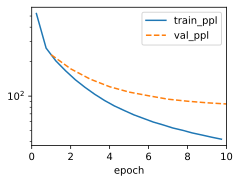

In [8]:
trainer = d2l.Trainer(max_epochs=10, gradient_clip_val=1, num_gpus=1)
model.board.yscale = 'log'
start = time.time()
trainer.fit(model, data)
fit_time = time.time() - start

In [9]:
def val_ppl(model):
    total_loss = num_tokens = 0
    for X_val, y_val in data.val_dataloader():
        losses = model.loss(model(X_val), y_val, averaged=False)
        total_loss += float(losses.sum())
        num_tokens += losses.size
    return math.exp(total_loss / num_tokens)

pred = model.predict('the time traveller', 30, data.tokenizer)
print(f'validation perplexity {val_ppl(model):.1f}, '
      f'{fit_time:.0f}s wall clock')
print(pred)

validation perplexity 85.3, 16s wall clock
the time traveller.

'I had
dism.

'I had
dism.

'I had
dism


In our runs the minGRU's validation perplexity comes in a few points
behind the GRU of that section (low-to-mid eighties versus high
seventies to low eighties under the identical recipe), despite having
input-only gates and roughly a quarter of the GRU's recurrent parameters,
at $2h(d+1)$
versus $3h(d+h+1)$ weights. The claim here is deliberately modest: not
that the minGRU is better, but that very little of the GRU's quality is
lost at this scale while the training computation becomes a parallel
scan. At 32-step windows the
sequential loop was never the bottleneck; the wall-clock argument is the
benchmark above, whose gap keeps widening as sequences grow. What
the stripped cell *does* give up is any dependence of the gates on the
state: the decay $\mathbf{a}_t$ is decided by the current input alone.
Hold that thought; it returns as the central limitation at the end of this
section.

## State Space Models

The minGRU linearized an RNN by deletion. State space models arrive at the
same destination from the opposite direction, starting from a classical
object with sixty years of control-theory pedigree: the continuous-time
linear dynamical system

$$
\dot{\mathbf{x}}(t) = \mathbf{A}\, \mathbf{x}(t) + \mathbf{B}\, u(t),
\qquad
y(t) = \mathbf{C}\, \mathbf{x}(t) + D\, u(t),
$$

in which a scalar input signal $u(t)$ drives a hidden state
$\mathbf{x}(t) \in \mathbb{R}^N$ through the *state matrix*
$\mathbf{A} \in \mathbb{R}^{N \times N}$ and input vector
$\mathbf{B} \in \mathbb{R}^{N}$, and a scalar output $y(t)$ reads the
state through $\mathbf{C} \in \mathbb{R}^{1 \times N}$ plus a direct
skip term $D u(t)$. (For vector-valued sequences we will simply run one
such system per feature channel.)

Why go continuous when our data are discrete tokens or pixels? Because
the equation parameterizes *dynamics*, a law of motion, rather
than a table of per-step transition weights. The law is independent of
how finely we sample it: one extra scalar, a step size $\Delta$, converts
the same $(\mathbf{A}, \mathbf{B})$ into a recurrence at any rate, so
resolution becomes a knob rather than something baked into the weights.
Better still, the conversion has a closed form that will hand us, for
free, the gate that that section had to engineer by hand.

### Discretization: the Step Size is a Gate

To turn the equation into a recurrence, hold the input constant
over each sampling interval of length $\Delta$ (a *zero-order hold*, ZOH)
and integrate the ODE exactly across the interval. For the linear system
this integral is explicit, giving the discrete recurrence

$$
\mathbf{x}_t = \bar{\mathbf{A}}\, \mathbf{x}_{t-1} + \bar{\mathbf{B}}\, u_t,
\qquad
y_t = \mathbf{C}\, \mathbf{x}_t + D\, u_t,
$$

with

$$
\bar{\mathbf{A}} = \exp(\Delta \mathbf{A}),
\qquad
\bar{\mathbf{B}} = \left( \int_0^{\Delta} \exp(\tau \mathbf{A})\, d\tau \right) \mathbf{B},
$$

where $\exp$ is the matrix exponential: the state decays under the flow
for a full interval, while the held input is carried in by the flow from
every instant $\tau$ at which it entered. The integral is the definition;
when $\mathbf{A}$ is invertible it has the familiar closed form
$\bar{\mathbf{B}} = \mathbf{A}^{-1}(\exp(\Delta \mathbf{A}) -
\mathbf{I})\, \mathbf{B}$, and for singular $\mathbf{A}$ the integral
still exists (at $\mathbf{A} = \mathbf{0}$ it is simply $\Delta
\mathbf{B}$). (A cruder alternative, the Euler
step $\bar{\mathbf{A}} \approx \mathbf{I} + \Delta \mathbf{A}$, is the
subject of an exercise.) In practice $\mathbf{A}$ is taken *diagonal*,
$\mathbf{A} = \mathrm{diag}(a_1, \ldots, a_N)$, which costs surprisingly
little modeling power and makes the equation elementwise:

$$
\bar{a}_n = e^{\Delta a_n},
\qquad
\bar{b}_n = \frac{e^{\Delta a_n} - 1}{a_n}\, b_n
\quad (a_n \neq 0; \textrm{ the limit at } a_n = 0 \textrm{ is } \Delta b_n).
$$

One numerical note travels with the equation: for small
$|\Delta a_n|$ the numerator $e^{\Delta a_n} - 1$ cancels catastrophically
in floating point, so code should call `expm1`, which computes
$e^x - 1$ accurately near zero. Our implementations below do.

Now make $\Delta$ a *learnable parameter* and watch what it does.

> **The step size is a gate.** As $\Delta \to 0$, we get
> $\bar{\mathbf{A}} \to \mathbf{I}$ and $\bar{\mathbf{B}} \to \mathbf{0}$:
> the state copies itself forward and ignores the input, a frozen memory.
> As $\Delta$ grows (with the real parts of the eigenvalues of
> $\mathbf{A}$ negative), $\bar{\mathbf{A}} \to \mathbf{0}$ and the state
> is rewritten from the current input alone. A learned $\Delta$ is
> therefore an update gate in the sense of that section,
> interpolating between "remember everything" and "overwrite everything",
> except that it was not bolted on: it fell out of asking how fast a
> continuous memory should run. This one correspondence is the bridge
> between the gated RNNs behind us and the selective models ahead, where
> $\Delta$ becomes input-dependent and gating is rediscovered a third
> time.

The correspondence becomes an identity, not an analogy, in one worked
scalar case. Discretize the
same ODE with the *backward* Euler rule instead of the ZOH and, for
the scalar mode $a = -1$, $b = 1$, the update becomes
$x_t = (1 - z)\, x_{t-1} + z\, u_t$ with
$z = \Delta / (1 + \Delta)$; store the step size in log space, as we are
about to, and $z = \sigma(\log \Delta)$ is *exactly* a sigmoid gate. A
GRU-style gated update is the backward-Euler discretization of this
scalar mode, with the gate's pre-activation
playing the role of the log step size [@Gu.2023]. Keep the scope of
the identity in view: for general matrix $\mathbf{A}$ the backward-Euler
transition $(\mathbf{I} - \Delta \mathbf{A})^{-1}$ is matrix-valued and
each mode carries its own decay and tied input response, so not every
discretized SSM is a GRU-style update. The gates that
that section engineered and the step size that calculus hands us
here are, in this scalar case, one object seen through two
discretization rules.

ZOH and backward Euler are two entries in a standard menu. The rules
differ in the transition they produce, in whether they preserve
stability, and in what happens when the sampling rate changes:

| Rule | $\bar{\mathbf{A}}$ | $\mathrm{Re}(a) < 0$ maps to | Accuracy | Changing $\Delta$ |
| :-- | :-- | :-- | :-- | :-- |
| Zero-order hold | $e^{\Delta \mathbf{A}}$ | $\lvert\bar{a}\rvert < 1$, always | exact for piecewise-constant input | rediscretize; stays stable |
| Bilinear (Tustin) | $(\mathbf{I} - \tfrac{\Delta}{2}\mathbf{A})^{-1}(\mathbf{I} + \tfrac{\Delta}{2}\mathbf{A})$ | $\lvert\bar{a}\rvert < 1$, always | second order in $\Delta$ | rediscretize; stays stable |
| Forward Euler | $\mathbf{I} + \Delta \mathbf{A}$ | $\lvert 1 + \Delta a\rvert < 1$ only for small $\Delta$ | first order in $\Delta$ | a coarser $\Delta$ can destabilize |
| Backward Euler | $(\mathbf{I} - \Delta \mathbf{A})^{-1}$ | $\lvert\bar{a}\rvert < 1$, always | first order in $\Delta$ | rediscretize; stays stable |

The choice is less about accuracy than about guarantees: every rule but
forward Euler maps the stable half-plane into the stable disk for any
$\Delta$. S4 used the bilinear transform [@Gu.Goel.Re.2022]; we use
ZOH throughout this chapter, as Mamba does (with a further first-order
simplification we meet in that section); forward Euler earns its
place in the exercise that shows how it fails.

Stability, which that section taught us to
fear, is now a matter of *parameterization* rather than luck. Store
$a_n$ as $-e^{\theta_n}$ (or any form pinned to the left half-plane), and
the discrete eigenvalues satisfy

$$
|\bar{a}_n| = e^{\Delta\, \mathrm{Re}(a_n)} < 1
\quad \textrm{whenever } \mathrm{Re}(a_n) < 0,
$$

for *every* value of the learned parameters: the spectral radius lives
inside the unit circle *by construction*, and no gradient update can push
the recurrence into the exploding regime. One scoping remark keeps this
claim exact. For a *diagonal* — hence normal — $\mathbf{A}$, the
eigenvalue bound controls every transient too: each coordinate shrinks at
every single step. A general non-normal matrix is slipperier, since its
powers can grow substantially for many steps before eigenvalue decay
wins (that section); every $\mathbf{A}$ this
chapter trains is diagonal, so the stronger, per-step reading applies.
Contrast the vanilla RNN, whose
$\mathbf{W}_{\textrm{hh}}$ had to be coaxed toward the knife-edge
$\rho \approx 1$ by clipping and prayer. Allowing complex $a_n$
(conjugate pairs) adds rotation to the decay: each state dimension
becomes a damped oscillator with a learned frequency, enriching the
dynamics at no cost to stability. For everything we train below, plain
negative-real $a_n$ suffices.

> **Four meanings of "stable".** The word is doing several jobs in this
> chapter, and they are not interchangeable. *Asymptotic (internal)
> stability*: the autonomous state decays, $\mathbf{x}_t \to \mathbf{0}$;
> for our diagonal systems this is exactly $|\bar{a}_n| < 1$, and it is
> what "by construction" above means. *BIBO stability*: bounded inputs
> yield bounded outputs; internal stability implies it here, though the
> two can part ways when an unstable mode hides from the output (a story
> told below). *Nonexpansive transition*: a single step never increases
> the state norm — a stronger per-step property that returns for the
> delta-rule transitions of that section. *Numerical
> stability*: the floating-point computation neither loses accuracy nor
> overflows; a mathematically stable scan can still hit it (notes at the
> end of this subsection).

A last word on precision, since discretized recurrences live or die by
it. Three habits cover this chapter. First, compute $e^x - 1$ with
`expm1`, as above. Second, respect what the scan does to rounding: it
*reassociates* a length-$T$ product of decays, so its output matches the
sequential loop only to float tolerance, never bitwise — every check in
this chapter compares against a tolerance scaled to the dtype. Third,
watch long products: with all $|\bar{a}| < 1$ a product of $T$ decays
underflows gracefully toward zero, but *ratios* of separately
exponentiated prefix products, which the chunked forms of
that section are built from, can overflow; log-domain and
chunk-rescaled implementations are the production answer.

### Recurrence is Convolution

The system the equation is linear and *time-invariant* (LTI): the
same $\bar{\mathbf{A}}, \bar{\mathbf{B}}, \mathbf{C}$ act at every step.
Unroll the recurrence from $\mathbf{x}_0 = \mathbf{0}$ and every output
becomes a weighted sum of all past inputs:

$$
y_t = \sum_{k=0}^{t-1} \mathbf{C} \bar{\mathbf{A}}^{k} \bar{\mathbf{B}}\, u_{t-k} + D\, u_t
= (\bar{\mathbf{K}} * \mathbf{u})_t + D\, u_t,
\qquad
\bar{\mathbf{K}} = (\mathbf{C}\bar{\mathbf{B}},\
\mathbf{C}\bar{\mathbf{A}}\bar{\mathbf{B}},\
\mathbf{C}\bar{\mathbf{A}}^2\bar{\mathbf{B}}, \ldots).
$$

That is a plain causal convolution, with a kernel $\bar{\mathbf{K}}$ as
long as the sequence itself, materialized from three small matrices. One
model is thus three models (the figure): a continuous ODE
(elegant for analysis and parameterization), a recurrence (constant-state
inference, one token at a time), and a convolution (parallel training).
The S4 line of work trains through this convolutional view, computing
$\bar{\mathbf{K}}$ and applying it with FFTs in $O(T \log T)$ time
[@Gu.Goel.Re.2022]; it is a beautiful trick, but it leans on
time-invariance, and the next section will make the dynamics
input-dependent precisely to gain selectivity. The parallel scan covers
both cases, so the scan is the path we implement.

![Three views of one linear state space model. Left: a continuous-time ODE responds to an input pulse. Middle: the discretized system is a linear recurrence, one step per token. Right: unrolled, the same system is a causal convolution whose kernel collects the impulse response.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-modernrnn-ssm-views.svg)

Seeing is believing: for a random diagonal SSM we now compute the same
outputs three ways, with the sequential recurrence, with the parallel
scan, and by convolving with the materialized kernel from
the equation (we drop the $D$ skip here, since all three views
share it verbatim).

In [10]:
num_states, num_steps, delta = 8, 64, 0.1
a = -jnp.arange(1., num_states + 1)                 # Re(a) < 0
b, c = jnp.ones(num_states), jax.random.normal(d2l.get_key(), (num_states,))
a_bar = jnp.exp(delta * a)                          # Zero-order hold
b_bar = jnp.expm1(delta * a) / a * b                # expm1: accurate e^x - 1
u = jax.random.normal(d2l.get_key(), (num_steps,))

def step(x, u_t):                                   # (i) recurrence
    x = a_bar * x + b_bar * u_t
    return x, jnp.dot(c, x)
_, y_loop = jax.lax.scan(step, jnp.zeros(num_states), u)

xs = associative_scan(jnp.tile(a_bar, (num_steps, 1)),
                      b_bar * u[:, None])           # (ii) parallel scan
y_scan = xs @ c

k = jnp.arange(num_steps)[:, None]                  # (iii) convolution
kernel = (c * b_bar * a_bar ** k).sum(-1)
y_conv = jnp.array(np.convolve(u, kernel)[:num_steps])

print(f'scan vs loop: {float(jnp.abs(y_scan - y_loop).max()):.2e}, '
      f'conv vs loop: {float(jnp.abs(y_conv - y_loop).max()):.2e}')

scan vs loop: 8.94e-08, conv vs loop: 1.19e-07


The three views agree to floating-point precision. Each is the right tool
for a different job, and the freedom to switch among them at will is the
practical superpower of keeping the recurrence linear.

### What Control Theory Already Knew

State space models were not invented for deep learning: they are the
core formalism of 1960s control theory, and four of its ideas earn their
keep in this chapter. All four show up in the smallest interesting
example, a two-state diagonal system

$$
\dot{\mathbf{x}}(t) = \begin{pmatrix} -1 & 0 \\ 0 & -2 \end{pmatrix} \mathbf{x}(t) + \mathbf{B}\, u(t),
\qquad
y(t) = \mathbf{C}\, \mathbf{x}(t).
$$

*Controllability and observability.* With $\mathbf{B} = (1, 0)^\top$ the
input never touches the second state: that mode is *uncontrollable*, and
no input signal can move it off its decay. With $\mathbf{C} = (1, 0)$
the output never sees it: the mode is *unobservable*. Either way, the
two-state system behaves at its terminals exactly like a one-state
system. State size is an upper bound on dynamical richness, not a
measurement of it — worth remembering whenever a later section prices a
model by its state, since $N$ counts coordinates, not used memory.

*Transfer function and poles.* Solved in the frequency domain, the LTI
system is multiplication by the *transfer function*
$H(s) = \mathbf{C}(s\mathbf{I} - \mathbf{A})^{-1}\mathbf{B}$, a rational
function whose poles are a subset of the eigenvalues of $\mathbf{A}$.
For the example with $\mathbf{B} = (1, 0)^\top$ and
$\mathbf{C} = (1, 1)$, $H(s) = 1/(s+1)$: one pole, not two, because the
unreachable mode cancels. The impulse response — our convolution kernel
the equation — is the same object in the time domain; the
kernel view above is control theory's oldest view, rediscovered.

*Internal versus BIBO stability.* The cancellation is also where the two
stability notions of the box above part ways: a system can be BIBO
stable, with bounded inputs producing bounded outputs, while an unstable
mode grows unseen because it is hidden from the output. Internal
stability, every mode decaying, is the stronger certificate, and it is
the one our left-half-plane parameterization provides.

*Similarity and non-identifiability.* Change state coordinates by any
invertible $\mathbf{T}$, sending $(\mathbf{A}, \mathbf{B}, \mathbf{C})$
to $(\mathbf{T}\mathbf{A}\mathbf{T}^{-1}, \mathbf{T}\mathbf{B},
\mathbf{C}\mathbf{T}^{-1})$, and the input–output map is unchanged. The
state is a coordinate system, not a canonical object. That freedom is
why restricting $\mathbf{A}$ to diagonal form (as S4D will) is less of a
sacrifice than it looks, and why two different-looking recurrences can
compute one function — a theme that returns as the state-space duality
of that section. For the classical theory at full
strength, see @Astrom.Murray.2021 .

A scope note, finally, because the term is older than our usage of it.
In statistics and signal processing a "state space model" is usually
*stochastic*: process noise drives the state, observation noise corrupts
the output, and the computational problem is inference — recovering a
posterior over the latent trajectory, by the Kalman filter
[@Kalman.1960] in the linear-Gaussian case and by particle methods
beyond it, with system identification as the matching learning problem.
The SSMs of this chapter share the state equation but not the problem:
they are deterministic feature extractors trained by backpropagation,
with no noise model and no posterior. The shared name records lineage,
not equivalence.

## Remembering the Past: HiPPO

One question remains before we can call this a principled design: what
should $\mathbf{A}$ *be*? Stability constrains its eigenvalues to the left
half-plane but otherwise leaves $N^2$ (or $N$ diagonal) numbers to choose,
and early attempts to train SSMs from random initializations performed
poorly. The question has a crisp mathematical form. The state
$\mathbf{x}(t)$ is a fixed budget of $N$ numbers summarizing the input
seen so far; which $N$ numbers lose the least?

HiPPO (high-order polynomial projection operators) is the answer
[@Gu.Dao.Ermon.ea.2020]. Fix a measure over the past, say uniform
weight on everything seen so far, and ask that $\mathbf{x}(t)$ hold the
$N$ coefficients of the best *orthogonal polynomial approximation* (of
degree less than $N$) of the input's history under that measure, the same
least-squares projection that powers Fourier and Legendre series. The remarkable
theorem is that this optimal compression can be maintained *online*: as
new input arrives, the optimal coefficients evolve according to a
linear, *time-varying* ODE,

$$
\dot{\mathbf{x}}(t) = \frac{1}{t} \left( \mathbf{A}\, \mathbf{x}(t) + \mathbf{B}\, u(t) \right),
$$

with a specific, input-independent matrix. For the uniform ("scaled
Legendre", LegS) measure it is

$$
A_{nk} = -\begin{cases}
\sqrt{(2n+1)(2k+1)} & \textrm{if } n > k, \\
n + 1 & \textrm{if } n = k, \\
0 & \textrm{if } n < k,
\end{cases}
\qquad
B_n = \sqrt{2n + 1},
$$

for $n, k = 0, \ldots, N-1$. We state the matrix and cite the
derivation; the $1/t$, though, deserves a sentence, because it is what
makes the equation *not* an instance of the LTI system
the equation. The measure spreads uniform weight over all of
$[0, t]$, so by time $t$ each new instant is only a $1/t$ fraction of
the history it joins, and the dynamics must slow down accordingly:
discretized at unit steps the update is
$\mathbf{x}_k = (\mathbf{I} + \mathbf{A}/k)\, \mathbf{x}_{k-1} +
(\mathbf{B}/k)\, u_k$, a recurrence whose effective step size decays
like $1/k$ rather than holding constant. (A pleasant consequence: the
system has no timescale $\Delta$ to tune, because rescaling time maps
its trajectories onto themselves.) What the theorem buys is shown in
the figure, whose generator integrates exactly
this time-varying system: a signal is compressed online into a LegS
state of size $N$ and then reconstructed from the state alone at the
final time. With $N = 64$
numbers, a thousand-step history is recovered almost perfectly, smoothing
only the sharpest transients. A fixed-size state provably *can* carry a
long past, provided its dynamics are chosen for the job.

![Compressing a function into $N$ numbers, online. A HiPPO-LegS state of size $N$ is updated as the signal (black) streams in; afterwards, the full history is reconstructed (color) from the final state alone. Larger states recover the past in increasing detail.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-modernrnn-hippo-reconstruction.svg)

### From HiPPO to S4 to S4D

The path from this theorem to the layer we implement passes through
three different objects, and it pays to keep them distinct.

*The online LegS projection* is the time-varying system
the equation. It, and only it, carries the optimality theorem:
run those dynamics and the state is, at every moment, the best
degree-$N$ polynomial summary of the entire past under the uniform
measure.

*S4 is an LTI model initialized at the HiPPO matrix.* S4
[@Gu.Goel.Re.2022] freezes the equation into the
time-invariant system the equation, adds a learnable step size
per channel, and trains everything by gradient descent. The optimality
theorem does not transfer — a time-invariant system maintains no
uniform-measure projection; tracking one is precisely what the $1/t$ was
for — but the HiPPO matrix proved to be a superb *initialization*,
giving the state a spread of decay timescales and long-memory structure
that random matrices lack. Speed came from structure: the HiPPO matrix
is *normal plus low-rank* (NPLR), so it is unitarily similar to a
diagonal-plus-low-rank (DPLR) matrix with complex-conjugate modes, and
with that form the convolution kernel the equation reduces to
Cauchy-kernel evaluations computable in near-linear time — machinery we
cite rather than rebuild. The payoff landed on the Long Range Arena
benchmark [@Tay.Dehghani.Abnar.ea.2021]: tasks with dependencies
over 16,000 steps, solved ahead of every transformer of S4's day.

*S4D is the diagonal approximation.* Drop the low-rank correction and
keep a diagonal state matrix, collapsing the machinery to the
elementwise formulas the equation. @Gu.Gupta.Goel.Re.2022
supply the evidence that this step is safe: suitably initialized
diagonal systems approximate S4's kernel as the state grows and match
its accuracy across the Long Range Arena in practice. The simplest of
their initializations is the one we implement below, real
$a_n = -(n + 1)$, the diagonal of the equation. Be clear about what
that inherits and what it does not: it is a *multiscale initialization*,
a bank of decay rates from slow to fast, not the optimal Legendre
projection — the theorem stays behind with the time-varying system, and
the case for the diagonal toy is the S4D paper's empirical one. Finally,
S5 [@Smith.Warrington.Linderman.2023] replaced the per-channel
FFTs with one multi-input state space layer evaluated by the
parallel scan, the same computational pattern we built above. Our
implementation sits deliberately at the intersection: S4D's diagonal
parameterization, S5's scan.

## S4D in Practice

Time to assemble a working network. The `S4D` layer below runs one
independent scalar SSM per feature channel, each with $N$ internal states:
its parameters are the diagonal $\mathbf{a}$ (stored as
$-e^{\log \textrm{magnitude}}$ to pin eigenvalues to the left half-plane,
initialized to $-(n+1)$), a per-channel learnable step size $\Delta$
(stored as $\log \Delta$, initialized log-uniformly between $10^{-3}$ and
$10^{-1}$, so different channels start as gates of very different speeds),
the read-out $\mathbf{C}$, and the skip $D$; following S4D we fix
$\mathbf{B} = \mathbf{1}$ and let $\mathbf{C}$ absorb its scale. The
forward pass is three lines of ZOH followed by the scan from
that section; since the dynamics are time-invariant,
the decay coefficients are the same at every position, and broadcasting
(a singleton batch axis for `a`) spares us materializing them per element.
We save the layer, and the block that follows, in the `d2l` library: the
next section builds directly on both.

In [11]:
class S4D(nnx.Module):
    """A diagonal state space layer: one SSM per feature channel."""
    def __init__(self, num_hiddens, num_states=4, dt_min=0.001, dt_max=0.1,
                 rngs=None):
        rngs = nnx.Rngs(0) if rngs is None else rngs
        H, N = num_hiddens, num_states
        self.log_a = nnx.Param(jnp.tile(jnp.log(jnp.arange(1., N + 1)),
                                        (H, 1)))
        self.log_dt = nnx.Param(
            rngs.params.uniform((H, 1)) * math.log(dt_max / dt_min)
            + math.log(dt_min))
        self.C = nnx.Param(rngs.params.normal((H, N)) / math.sqrt(N))
        self.D = nnx.Param(jnp.ones(H))

    def __call__(self, u):                   # (num_steps, batch, num_hiddens)
        a = -jnp.exp(self.log_a[...])                 # (H, N), Re(a) < 0
        da = jnp.exp(self.log_dt[...]) * a
        a_bar = jnp.exp(da)
        b_bar = jnp.expm1(da) / a                     # ZOH with B = 1
        a_elems = jnp.broadcast_to(                   # Same at every step
            a_bar[None, None], (u.shape[0], 1, *a_bar.shape))
        b_elems = b_bar * u[..., None]                # (T, batch, H, N)
        x = associative_scan(a_elems, b_elems)
        return (x * self.C).sum(-1) + self.D * u

A single `S4D` layer mixes information across *time* but never across
*channels* (each channel owns a private SSM), and it is linear. Both gaps
are closed the modern way, by wrapping the layer in a residual block with
normalization and a gated MLP (the figure): the MLP mixes
channels and supplies the nonlinearity that the state path gave up, and
the gate is one more echo of that section. Stacking $L$ such blocks
yields the standard deep SSM of the S4/S4D/S5 papers.

![The S4D residual block: sequence mixing by a per-channel diagonal SSM, channel mixing by a gated MLP, each behind LayerNorm with a residual connection, stacked $L$ times.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-modernrnn-ssm-block.svg)

In [12]:
class S4DBlock(nnx.Module):
    def __init__(self, num_hiddens, num_states, rngs=None):
        rngs = nnx.Rngs(0) if rngs is None else rngs
        self.ln1 = nnx.LayerNorm(num_hiddens, rngs=rngs)
        self.ssm = S4D(num_hiddens, num_states, rngs=rngs)
        self.ln2 = nnx.LayerNorm(num_hiddens, rngs=rngs)
        self.W_v = nnx.Linear(num_hiddens, 2 * num_hiddens, rngs=rngs)
        self.W_g = nnx.Linear(num_hiddens, 2 * num_hiddens, rngs=rngs)
        self.W_o = nnx.Linear(2 * num_hiddens, num_hiddens, rngs=rngs)

    def __call__(self, X):
        X = X + self.ssm(self.ln1(X))
        Y = self.ln2(X)
        return X + self.W_o(self.W_v(Y) * jax.nn.sigmoid(self.W_g(Y)))

### Sequential Image Classification

Where should a long-memory architecture prove itself? A classic stress
test is *sequential image classification*: feed a model the
Fashion-MNIST images of that section one pixel at a time,
as a plain sequence of 784 scalars, and predict the class. No
spatial structure is given: any relation between pixel 3 and pixel 787
must travel through the sequence model. How it is allowed to travel is
decided by the *readout*, and the choice changes what the experiment
measures. Mean-pooling all 784 per-step outputs is the standard
benchmark form of the task: every pixel contributes through its own
output, so the score measures how well the encoder *mixes* information
across the sequence, not whether anything survives to the end. Reading
only the *final* step's features is the sterner retention diagnostic:
whatever the model uses must still be present in the state after
hundreds of updates. The classifier below embeds
each pixel, runs an encoder over the sequence, and supports both
readouts; it accepts any encoder with our
`(num_steps, batch, features)` calling convention, which lets us swap an
S4D stack against an LSTM without touching anything else. We train with
Adam (that section), whose per-parameter step sizes suit
a model that mixes log-decays with ordinary linear weights; plain SGD
handles the SSM's exponentials awkwardly.

In [13]:
class SeqClassifier(d2l.Classifier):
    """Classify a sequence: encoder, then mean or final-step readout."""
    def __init__(self, encoder, num_hiddens, num_features=None, pool='mean',
                 lr=3e-3, rngs=None):
        super().__init__()
        self.save_hyperparameters(ignore=['encoder', 'rngs'])
        rngs = nnx.Rngs(1) if rngs is None else rngs
        num_features = num_hiddens if num_features is None else num_features
        self.encoder = encoder
        self.emb = nnx.Linear(1, num_hiddens, rngs=rngs)
        self.head = nnx.Linear(num_features, 10, rngs=rngs)

    def forward(self, X):
        X = X.reshape(X.shape[0], -1, 1).transpose(1, 0, 2)  # Pixel sequence
        Y = self.encoder(self.emb(X))
        Y = Y[0] if isinstance(Y, tuple) else Y         # RNNs return a state
        return self.head(Y.mean(axis=0) if self.pool == 'mean' else Y[-1])

    def configure_optimizers(self):
        return optax.adam(self.lr)

Our S4D model stacks two blocks of width 48 with $N = 4$ states per
channel; the baseline is the LSTM of that section sized to the same
parameter count (48-dimensional pixel embeddings, 64 hidden units,
roughly 30,000 parameters each), trained under the benchmark mean-pool
readout. Ten epochs each, identical data
pipeline, identical head, and gradients clipped to norm 1 for both
models: at 784 steps the LSTM otherwise destabilizes mid-training, its
loss spiking exactly as that section would
predict, while the S4D, whose recurrence cannot leave the unit circle,
reaches the same accuracy with or without clipping.

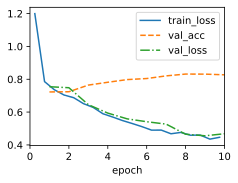

In [14]:
data = d2l.FashionMNIST(batch_size=128)
results = {}

def train_and_report(name, model, epochs=10):
    trainer = d2l.Trainer(max_epochs=epochs, gradient_clip_val=1, num_gpus=1)
    start = time.time()
    trainer.fit(model, data)
    params = sum(p.size for p in
                 jax.tree.leaves(nnx.state(model, nnx.Param)))
    results[name] = (params, float(model.board.data['val_acc'][-1].y),
                     (time.time() - start) / epochs)

s4d = SeqClassifier(nnx.Sequential(*[S4DBlock(48, 4) for _ in range(2)]),
                    num_hiddens=48)
train_and_report('S4D', s4d)

The retention diagnostic is the same mixer read only at the final step,
one more training run.

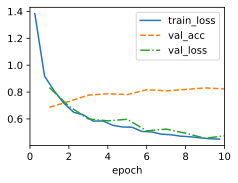

In [15]:
s4d_final = SeqClassifier(
    nnx.Sequential(*[S4DBlock(48, 4) for _ in range(2)]),
    num_hiddens=48, pool='last')
train_and_report('S4D (final)', s4d_final)

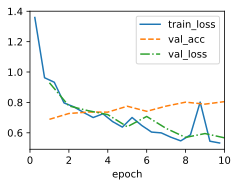

In [16]:
lstm = SeqClassifier(d2l.LSTM(num_inputs=48, num_hiddens=64),
                     num_hiddens=48, num_features=64)
train_and_report('LSTM', lstm)

In [17]:
print(f'{"model":>12} {"params":>8} {"val acc":>8} {"s/epoch":>8}')
for name, (params, acc, secs) in results.items():
    print(f'{name:>12} {params:>8,} {acc:>8.3f} {secs:>8.1f}')

       model   params  val acc  s/epoch
         S4D   30,058    0.827      6.1
 S4D (final)   30,058    0.823      5.8
        LSTM   29,674    0.805     48.6


Read the table one comparison at a time. On the mean-pool benchmark the
S4D lands in the low-to-mid eighties in both frameworks
and every rerun, clipped or unclipped. The final-state run answers the
retention question the mean pool cannot: reading nothing but the state
after 784 updates costs the S4D little to nothing in our runs — the two
readouts finish within run-to-run noise of each other, at most a few
points apart and sometimes nearly tied — so what the classifier uses
genuinely survives to the end of the
sequence rather than being rescued by early outputs. The LSTM baseline
is another
story: across repeated runs (with and without clipping, at nearby
learning rates) its final accuracy has ranged from roughly 60 to 84
percent, and where a given run lands is a matter of initialization and
luck. Plain uniform recurrent weights (PyTorch's default) leave
long-range memory to chance; orthogonal recurrent weights (Flax's
default) improve the odds without securing them; reliably closing the
gap takes the rest of the folklore of that section, starting with
a forget-gate bias of 1. The contrast is the section's thesis in
miniature. At initialization the S4D's channels already implement a
bank of exponential memories with time constants spanning more than two
orders of magnitude (what the log-uniform $\Delta$ init provides), so
pixel-to-pixel structure hundreds of steps apart is visible to the model
from the first gradient step, in any framework; an LSTM holds long-range
state only when a decade's worth of initialization folklore is applied
on its behalf, and hopes for a lucky draw otherwise. What the SSM
parameterization provides — stability by construction and a multiscale
initialization — is that memory *by design*, robustly, rather than
by folklore. Wall-clock per epoch, also in the table,
depends on what each framework fuses: against PyTorch's cuDNN-fused LSTM
our teaching-grade scan pays its log-factor overhead, while in JAX,
where both models run compiled scans, the parallel scan is several times
faster than the sequential LSTM; production SSM kernels close the
remaining gap the same way cuDNN once did for the LSTM. On the Long
Range Arena [@Tay.Dehghani.Abnar.ea.2021], with sequences up to
16,000 steps, this architecture family was the first to solve tasks on
which both RNNs and transformers had failed, which is what first made
the field take state space models seriously.

## Inference, One Token at a Time

This section opened with a bargain: train in parallel, then run the model
the old recurrent way at inference, a fixed-size state updated in constant
time per token. We have delivered the first half with the scan and, so
far, only asserted the second. Time to collect. There is nothing to
derive: the equation *is* the inference algorithm. Given the last
state $\mathbf{x}_{t-1}$ and one new input $u_t$,

$$
\mathbf{x}_t = \bar{\mathbf{A}}\, \mathbf{x}_{t-1} + \bar{\mathbf{B}}\, u_t,
\qquad
y_t = \mathbf{C}\, \mathbf{x}_t + D\, u_t,
$$

and the state is all the model ever needs to remember: for our `S4D`
layer, one $N$-vector per channel, an $(H, N)$ block of numbers per
layer. The `step` method below advances that block by one token; the
matching method on `S4DBlock` threads the state through the layer while
the gated MLP, which acts position-wise, needs no state at all. Both go
into the `d2l` library next to their classes.

In [18]:
@d2l.add_to_class(S4D)
def step(self, u, x=None):
    """Advance one token: u is (batch, H); x is the (batch, H, N) state."""
    a = -jnp.exp(self.log_a[...])
    da = jnp.exp(self.log_dt[...]) * a
    a_bar = jnp.exp(da)                               # Same ZOH as forward
    b_bar = jnp.expm1(da) / a
    if x is None:
        x = jnp.zeros((*u.shape, a_bar.shape[-1]))
    x = a_bar * x + b_bar * u[..., None]              # One recurrence step
    return (x * self.C).sum(-1) + self.D * u, x

@d2l.add_to_class(S4DBlock)
def step(self, X, x=None):
    """Advance the block one token; only the SSM carries state."""
    y, x = self.ssm.step(self.ln1(X), x)
    X = X + y
    Y = self.ln2(X)
    return X + self.W_o(self.W_v(Y) * jax.nn.sigmoid(self.W_g(Y))), x

A claim of equivalence should be checked on a model whose answers we care
about, so we replay validation images through the *trained* classifier's
encoder both ways: all 784 pixels at once through the scan, then one
pixel at a time through `step`, carrying one state per block. The two
schedules perform the same arithmetic in different association orders,
so they can differ only by float32 rounding, and over 784 steps of
trained, near-unit decays that rounding accumulates; the comparison
must therefore be *relative* to the activation scale. The assertion
is a regression guard as much as a demonstration: a genuine mismatch
between `forward` and `step` shows up at relative errors near one, five
orders of magnitude above this gate.

In [19]:
X_val = jnp.asarray(next(iter(data.val_dataloader()))[0][:64])
seq = s4d.emb(X_val.reshape(X_val.shape[0], -1, 1).transpose(1, 0, 2))
# GPU matmuls default to TF32; run both schedules in full fp32 so the
# comparison isolates the reassociation error
with jax.default_matmul_precision('float32'):
    y_scan = s4d.encoder(seq)                    # All 784 steps at once
    states, ys = [None] * len(s4d.encoder.layers), []
    for t in range(seq.shape[0]):                # One pixel at a time
        X, new_states = seq[t], []
        for blk, x in zip(s4d.encoder.layers, states):
            X, x = blk.step(X, x)
            new_states.append(x)
        states, ys = new_states, ys + [X]
err = float(jnp.abs(jnp.stack(ys) - y_scan).max())
scale = float(jnp.abs(y_scan).max())
print(f'stepped vs scanned: deviation {err:.2e} '
      f'on activations of scale {scale:.0f}: relative {err / scale:.2e}')
assert err < 1e-3 * scale

stepped vs scanned: deviation 1.67e-03 on activations of scale 79: relative 2.12e-05


Now the stopwatch. Picture the model serving a stream, a batch of 32
sequences arriving one token at a time, and consider the cost of
absorbing the next token once $P$ tokens have already passed. Without a
carried state we would do what our training path does: re-run the scan
over all $P + 1$ positions, paying for the entire history again. With
the state, the past is already summarized and one `step` suffices. We
time both as the prefix grows.

carried state: 1536 bytes per sequence, at every prefix length


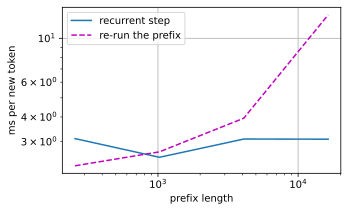

In [20]:
def one_step(model, X, states):
    for blk, x in zip(model.layers, states):
        X, x = blk.step(X, x)
    return X

step_fn = nnx.jit(one_step)
rerun_fn = nnx.jit(lambda model, seq: model(seq))

lengths, times = [256, 1024, 4096, 16384], [[], []]
states = [jnp.zeros((32, 48, 4)) for _ in s4d.encoder.layers]
X1 = jnp.zeros((32, 48))
for P in lengths:
    seq = jax.random.normal(jax.random.key(P), (P, 32, 48))
    times[0].append(wall_clock(step_fn, s4d.encoder, X1, states) * 1e3)
    times[1].append(wall_clock(rerun_fn, s4d.encoder, seq) * 1e3)
d2l.plot(lengths, times, 'prefix length', 'ms per new token',
         legend=['recurrent step', 're-run the prefix'],
         xscale='log', yscale='log', figsize=(5, 3))
print(f'carried state: {sum(4 * x.size for x in states) // 32} '
      f'bytes per sequence, at every prefix length')

The two curves have the shapes the theory promises. Re-running the
prefix costs more the longer the history, linearly once the sequence is
long enough for real work to dominate per-call overhead; the recurrent
step costs the same at every prefix length. How wide the gap has grown
by our longest prefix depends on the framework's per-call overhead
(severalfold to two orders of magnitude in our runs), and it keeps
widening for as long as the prefix, and the memory holding it, keep
growing. At this toy width the absolute
times are launch-overhead-bound, so read the shapes, not the
milliseconds.

The printed number is the punchline's other half. A transformer
generating with a KV cache also avoids re-running its prefix, but it
does so by *storing* the past: its cache grows linearly with context, at
a rate we measured in that section (tens of kibibytes per
token for even a small model), and serving budgets are set by that
growth. The recurrent model's entire memory of an arbitrarily long
history is the $(H, N)$ state per layer printed above, about a
kibibyte here, the same at token 100 as at token 100,000. This
constant-memory inference is why recurrent layers are back inside
production language models, and it is the prize for which linear
attention gave up its softmax in that section. What
the fixed-size state *costs*, and when it is worth paying, is a question
this chapter returns to once the selective models are on the table.

## Summary

Recurrence buys constant-memory inference but serializes training; this
section removed the serialization by making the state update linear. The
minGRU shows the deletion route: gates computed from the input alone turn
the GRU into an elementwise affine recurrence
$\mathbf{h}_t = \mathbf{a}_t \odot \mathbf{h}_{t-1} + \mathbf{b}_t$, which
an associative combine evaluates in $O(\log T)$ parallel rounds, at
language-modeling quality on par with the GRU. State space models reach
the same recurrence from first principles: discretizing continuous linear
dynamics yields the ZOH formulas, in which the learnable step size
$\Delta$ *is* an update gate and stability holds by construction, with
eigenvalues pinned inside the unit circle by parameterization rather than
by clipping (that section). Time-invariance
makes the same model a recurrence, a convolution, and an ODE at once.
HiPPO supplies dynamics under which a fixed-size state is a
provably good compression of the whole past — a time-varying system
whose matrix, frozen, initializes the LTI S4 family, with the diagonal
S4D as the empirically vindicated simplification we implement.
Assembled into residual
blocks, the S4D trains reliably on 784-step sequential image
classification where a plainly initialized,
parameter-matched LSTM succeeds only on a lucky draw, and it holds its
accuracy to within a few points when read from the final state alone,
the retention diagnostic. Finally we ran the trained model
the other way, one token at a time: stepping agrees with the scan to
floating-point accuracy, costs the same at any prefix length, and
carries a state a few hundred bytes per layer where a transformer's KV
cache grows with the length of the context (that section).

Everything here, though, is *linear and time-invariant*: the kernel
$\bar{\mathbf{K}}$, and with it the decision of what to remember, is fixed
before the model ever sees the input. An S4D *layer* cannot read a token
and decide that *this one* matters while its neighbor is noise: its
gates, unlike the LSTM's, do not look at the data as it flows past, so
the state-update operator is in this precise sense content-blind. The
qualifier matters: the blocks *around* each SSM are input-dependent, and
a deep stack can modulate between layers what it cannot modulate within
the state update — which is why such models earn partial credit, though
not success, on the selectivity task of the next section. Curing the
limitation at the operator level, and keeping the
scan, is the subject of that section.

**What the experiments show, and what they do not.** The scan-vs-loop
and step-vs-rerun benchmarks establish *shapes* (logarithmic against
linear, flat against growing), measured with teaching-grade kernels on
one GPU; they are not production throughput numbers. The equivalence
checks (scan against loop, stepping against scanning) are identities up
to float rounding, the strongest claims here. The classifier is one
seeded run per framework per readout: it shows that the multiscale
initialization trains reliably where the plainly initialized LSTM is at
the mercy of its draw, not a general architecture ranking.

## Exercises

1. [short-code] *Effective memory.* For a scalar recurrence
   $h_t = \bar{a} h_{t-1} + u_t$, define the effective memory horizon as
   the lag $k$ at which the influence $\bar{a}^k$ of an input drops below
   $0.01$. Plot the horizon as a function of $\bar{a} \in (0.9, 0.999)$
   and as a function of $\Delta$ under $\bar{a} = e^{-\Delta}$. How must
   $\Delta$ scale for the model to remember 10 times longer, and how does
   this connect the step-size-as-gate box to the eigenvalue analysis of
   that section?
1. [short-code] *ZOH versus Euler.* The Euler discretization uses
   $\bar{\mathbf{A}} = \mathbf{I} + \Delta \mathbf{A}$ and
   $\bar{\mathbf{B}} = \Delta \mathbf{B}$. For the scalar system
   $a = -1, b = 1$ driven by $u_t = \sin(0.1 t)$, compare Euler and ZOH
   outputs against a fine-grained reference solution for
   $\Delta \in \{0.1, 0.5, 1.0, 2.5\}$. Which discretization degrades
   gracefully, and what goes visibly wrong with Euler at $\Delta = 2.5$?
   (Check the eigenvalue $|1 + \Delta a|$ first.)
1. [short-code] *Kernels as fingerprints.* Materialize and plot the
   convolution kernel
   the equation for (a) our diagonal initialization
   $a_n = -(n+1)$ with $\mathbf{B} = \mathbf{1}$ and random $\mathbf{C}$,
   and (b) the LTI system that S4 initializes, the full (non-diagonal)
   HiPPO matrix the equation frozen into the equation, using
   matrix powers. How do the kernels differ in shape and in how much mass
   they place on the distant past?
1. [extended] *minLSTM.* Apply the minGRU recipe to the LSTM of that section:
   make all gates functions of the input only, drop the output gate's
   dependence on the state, and write the cell update
   $\mathbf{C}_t = \mathbf{F}_t \odot \mathbf{C}_{t-1} + \mathbf{I}_t
   \odot \tilde{\mathbf{C}}_t$ as an affine recurrence
   the equation. Implement it with `associative_scan`
   and train it with this section's language-modeling recipe. Does the
   extra gate help? (Compare @Feng.Tung.Ahmed.ea.2024, who also
   normalize the two gates to sum to one.)
1. [short-code] *The candidate nonlinearity.* Our minGRU keeps a $\tanh$ on the
   candidate $\tilde{\mathbf{H}}_t$, while @Feng.Tung.Ahmed.ea.2024
   use a purely linear candidate. Remove the $\tanh$ and retrain. What
   happens to training stability and final perplexity, and why does an
   unbounded candidate interact badly with a convex-combination update?
1. [short-code] *Streaming classification.* The stepped path of that section
   makes anytime prediction almost free: the classifier head only needs the
   running mean of the encoder features seen so far, which you can carry as
   one more piece of constant-size state. Stream validation images pixel by
   pixel, classify after every step, and plot accuracy as a function of
   pixels seen. After how many of the 784 pixels does the model commit to
   its final answer, and does the shape of that curve match what mean
   pooling would lead you to expect?
1. [short-code] *State passing.* The scan assumes $\mathbf{h}_0 = \mathbf{0}$, and
   `MinGRU` folds a carried state into $\mathbf{b}_1$. Use this to process
   a length-$T$ sequence in $T/\tau$ chunks of length $\tau$, passing the
   final state of each chunk into the next, and verify that the outputs
   match the unchunked scan to floating-point tolerance (chunking
   reassociates the arithmetic, so compare against a tolerance scaled to
   the dtype, not bitwise). Why might chunking be useful at
   training time? (Think memory, and recall truncated BPTT from
   that section.)

[Discussions](https://d2l.discourse.group/)